# Advanced Model Tuning with Optuna

Default parameters are a starting point. **Optuna** uses Bayesian optimization to find the best hyperparameters — automatically, efficiently, and with visual insights.

**Goals:**
1. 🔍 Optimize XGBoost parameters using Bayesian search
2. 📊 Visualize the optimization journey (history + importance)
3. Train the final model with the best-found parameters

In [2]:
# Loading libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import pathlib
import mlflow
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

try:
    from IPython.display import display
except ImportError:
    def display(obj): print(obj)

## Loading Data

In [3]:
# Load data & rebuild features (same logic as Churn Prediction notebook)
processed_dir = pathlib.Path.cwd().parent / 'data' / 'processed'
df = pd.read_csv(processed_dir / 'online_retail_initial.csv', parse_dates=['InvoiceDate'])

# Define churn window
max_date = df['InvoiceDate'].max()
cutoff_date = max_date - pd.Timedelta(days=90)

obs_df = df[df['InvoiceDate'] <= cutoff_date]
future_df = df[df['InvoiceDate'] > cutoff_date]
returning_customers = future_df['CustomerID'].dropna().unique()

# Feature engineering
snapshot_date = obs_df['InvoiceDate'].max() + pd.Timedelta(days=1)
X = obs_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()
X.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Labels: 0 = returned, 1 = churned
y = X['CustomerID'].apply(lambda x: 0 if x in returning_customers else 1)
X = X.drop('CustomerID', axis=1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
churn_ratio = (y == 0).sum() / (y == 1).sum()

print(f"👥 Training samples: {len(X_train):,} | Test samples: {len(X_test):,}")
print(f"📊 Churn rate: {y.mean()*100:.1f}% | Balance ratio: {churn_ratio:.1f}:1")

👥 Training samples: 4,276 | Test samples: 1,070
📊 Churn rate: 56.6% | Balance ratio: 0.8:1


## 2. Defining the Objective Function
The objective function tells Optuna what to maximize (ROC-AUC in our case).

In [4]:
def objective(trial):
    """Optimize XGBoost hyperparameters to maximize ROC-AUC."""
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'scale_pos_weight': churn_ratio,
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42
    }
    
    model = XGBClassifier(**param)
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds)
    return auc

# Run optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n🏆 Best AUC: {study.best_value:.4f}")
print(f"🔧 Best Params: {study.best_params}")

[I 2026-04-27 01:17:09,947] A new study created in memory with name: no-name-9afd4e92-dd2e-4431-b51d-f235c6c60256
Best trial: 0. Best value: 0.791149:   3%|▎         | 1/30 [00:01<00:39,  1.38s/it]

[I 2026-04-27 01:17:11,317] Trial 0 finished with value: 0.791149026926153 and parameters: {'n_estimators': 124, 'max_depth': 9, 'learning_rate': 0.1375886724853327, 'subsample': 0.9285414503721093, 'colsample_bytree': 0.9185598640057986, 'gamma': 0.0007610764370752337}. Best is trial 0 with value: 0.791149026926153.


Best trial: 1. Best value: 0.81654:   7%|▋         | 2/30 [00:02<00:33,  1.18s/it] 

[I 2026-04-27 01:17:12,363] Trial 1 finished with value: 0.8165395894428152 and parameters: {'n_estimators': 220, 'max_depth': 5, 'learning_rate': 0.016238076801030146, 'subsample': 0.9205563635425258, 'colsample_bytree': 0.7428128924074158, 'gamma': 0.0322902503265256}. Best is trial 1 with value: 0.8165395894428152.


Best trial: 1. Best value: 0.81654:  10%|█         | 3/30 [00:04<00:39,  1.44s/it]

...

[I 2026-04-27 01:17:42,745] Trial 27 finished with value: 0.8097378476850617 and parameters: {'n_estimators': 433, 'max_depth': 5, 'learning_rate': 0.04934031360128706, 'subsample': 0.8050380924318952, 'colsample_bytree': 0.8355081797888941, 'gamma': 2.851554887739281e-08}. Best is trial 24 with value: 0.8174424597885008.


Best trial: 24. Best value: 0.817442:  97%|█████████▋| 29/30 [00:34<00:01,  1.47s/it]

[I 2026-04-27 01:17:44,434] Trial 28 finished with value: 0.7895316804407714 and parameters: {'n_estimators': 314, 'max_depth': 8, 'learning_rate': 0.08873359630439102, 'subsample': 0.8496113919653637, 'colsample_bytree': 0.9643048811164043, 'gamma': 3.6332073692772484e-06}. Best is trial 24 with value: 0.8174424597885008.


Best trial: 24. Best value: 0.817442: 100%|██████████| 30/30 [00:34<00:00,  1.16s/it]

[I 2026-04-27 01:17:44,658] Trial 29 finished with value: 0.8159868479516574 and parameters: {'n_estimators': 101, 'max_depth': 4, 'learning_rate': 0.032690702892754595, 'subsample': 0.9479429791048212, 'colsample_bytree': 0.9106878600376592, 'gamma': 0.0001354513569828453}. Best is trial 24 with value: 0.8174424597885008.

🏆 Best AUC: 0.8174
🔧 Best Params: {'n_estimators': 395, 'max_depth': 4, 'learning_rate': 0.01213703219117234, 'subsample': 0.7985636132730647, 'colsample_bytree': 0.9465519012433267, 'gamma': 5.806059633442458e-05}


## 3. Visualization
Optuna provides interactive plots to understand the importance of each hyperparameter.

In [ ]:
# Optimization history — AUC improvement over trials
plot_optimization_history(study)
plt.tight_layout()
plt.show()

In [ ]:
# Hyperparameter importance — which params mattered most
plot_param_importances(study)
plt.tight_layout()
plt.show()

## 4. Final Model & Feature Importance
We train the model one last time using the discovered 'best' parameters.

🏆 Optimized AUC: 0.8174


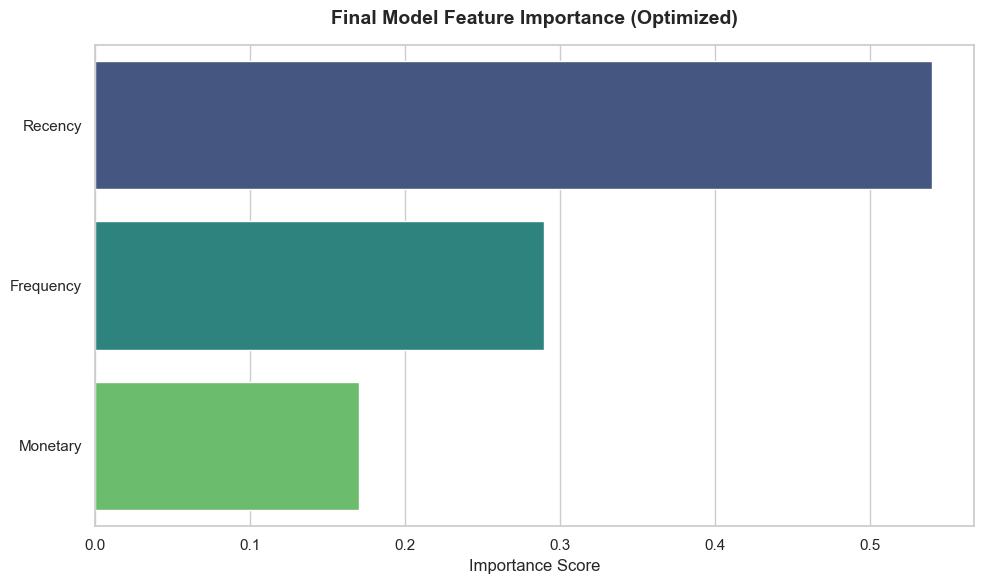

In [9]:
# Train best model
best_model = XGBClassifier(**study.best_params, scale_pos_weight=churn_ratio, random_state=42)
best_model.fit(X_train, y_train)

# Evaluate
y_prob = best_model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_prob)
print(f"🏆 Optimized AUC: {final_auc:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Final Model Feature Importance (Optimized)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. Saving Results

In [10]:
os.makedirs('../models', exist_ok=True)

# Save best hyperparameters
with open('../models/best_hyperparameters.json', 'w') as f:
    json.dump(study.best_params, f, indent=4)

# Save optimized model
best_model.save_model('../models/optimized_churn_model.json')

print("✅ Optimized model and hyperparameters saved to '../models/'.")

✅ Optimized model and hyperparameters saved to '../models/'.


## 6. Key Takeaways

- **Optuna improved AUC** from the default model by finding the best hyperparameter combination in just 30 trials.
- **Bayesian search beats grid search**: Smart exploration of the search space finds better params faster.
- **Recency dominates feature importance** — the longer a customer is inactive, the higher the churn risk.
- **Optimized model is production-ready**: Saved with best hyperparameters for deployment.

## 7. MLFlow Tracking

In [11]:
mlflow.set_tracking_uri(f"file:{pathlib.Path.cwd().parent / 'mlruns'}")
mlflow.set_experiment("RetailPulse_Optuna_Optimization")

with mlflow.start_run(run_name="XGBoost_Optuna_Tuning"):
    # Log best hyperparameters
    mlflow.log_params(study.best_params)
    
    # Log metrics
    mlflow.log_metric("Best_AUC", study.best_value)
    mlflow.log_metric("Final_AUC", final_auc)
    mlflow.log_metric("n_trials", 30)
    
    # Log artifacts
    mlflow.log_artifact('../models/best_hyperparameters.json')
    mlflow.log_artifact('../models/optimized_churn_model.json')

print("✅ Optuna optimization results logged to MLflow!")

2026/04/27 01:20:36 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse_Optuna_Optimization' does not exist. Creating a new experiment.


✅ Optuna optimization results logged to MLflow!
